<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_5/Day_3/Daily_challenge/DailyChallenge_Statfor_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Daily Challenge - Statistics for Machine Learning

# Applying Inferential Statistics

### Here are the hypotheses to test:
1. Age of people who left the bank and who did not are similar. Alternative: Not similar.
2. Credit score of people who left the bank and who did not are similar. Alternative: Not similar.
3. Balance of people who left the bank and who did not are similar. Alternative: Not similar.
4. Estimated Salary of people who left the bank and who did not are similar. Alternative: Not similar.

#### The most appropriate test to analyse data here is Frequentist test.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import scipy.stats
from scipy.stats import t
from scipy.special import stdtr
from numpy.random import seed
import seaborn as sns

%matplotlib inline
from matplotlib import rcParams
sns.set_style("whitegrid")
sns.set_context("poster")

In [33]:
matplotlib.rcParams['figure.figsize'] = (8.0, 5.0)

In [34]:
## TODO : load the csv file from this link : https://www.kaggle.com/code/vaibhagarwal/inferential-statistics/input
file_1 = pd.read_csv('Churn_Modelling.csv')

In [35]:
## TODO : make into a dataframe called df
df = pd.DataFrame(file_1)

In [36]:
## TODO : output the first 5 lines
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [37]:
## TODO : Create two separate DataFrames, `df_0` and `df_1`, to filter customers who have not exited (0) and customers who have exited (1), respectively
df_0 = df[df['Exited'] == 0]
df_1 = df[df['Exited'] == 1]

## Hypothesis 1: Age

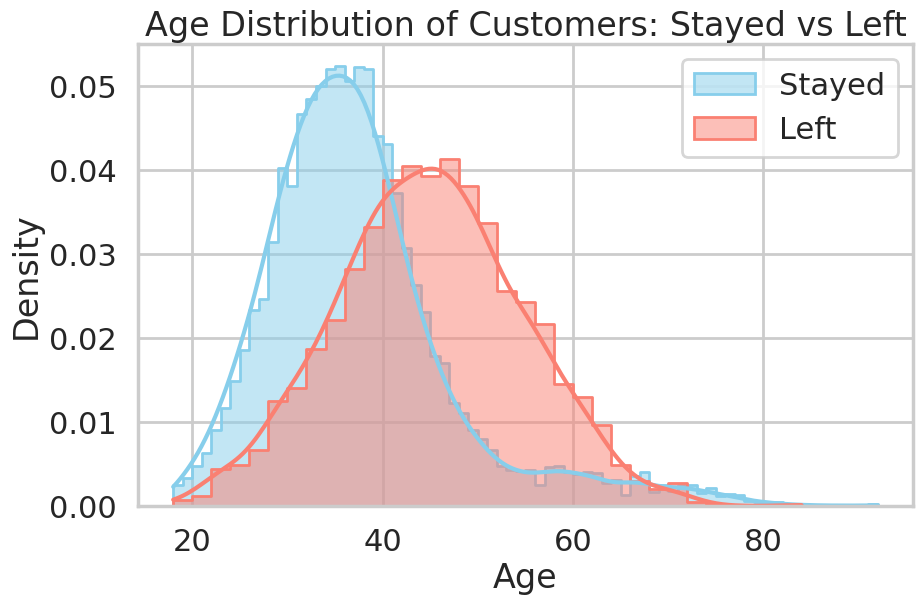

In [38]:
## TODO: Plot the age distribution for customers who stayed with the bank and those who left using seaborn, with different colors for each group and a legend.
plt.figure(figsize=(10, 6))
sns.histplot(df_0['Age'], color='skyblue', label='Stayed', kde=True, element='step', stat="density", common_norm=False)
sns.histplot(df_1['Age'], color='salmon', label='Left', kde=True, element='step', stat="density", common_norm=False)

plt.title('Age Distribution of Customers: Stayed vs Left')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

In [39]:
## TODO: Calculate the mean and standard deviation of the age for customers who stayed with the bank.
mean_age_0 = df_0['Age'].mean()
std_age_0 = df_0['Age'].std()

print(f"Mean Age (Stayed): {mean_age_0}")
print(f"Standard Deviation Age (Stayed): {std_age_0}")

Mean Age (Stayed): 37.40838879819164
Standard Deviation Age (Stayed): 10.125362911047631


In [40]:
## TODO: Calculate the mean and standard deviation of the age for customers who left the bank.
mean_age_1 = df_1['Age'].mean()
std_age_1 = df_1['Age'].std()

print(f"Mean Age (Left): {mean_age_1}")
print(f"Standard Deviation Age (Left): {std_age_1}")

Mean Age (Left): 44.8379970544919
Standard Deviation Age (Left): 9.761561555507132


In [41]:
## TODO: Perform a t-test to compare the ages of customers who stayed and left the bank.
from scipy import stats

t_stat, p_value = stats.ttest_ind(df_1['Age'], df_0['Age'], equal_var=False)

print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

T-statistic: 30.419197204406792
P-value: 4.7127272656641046e-179


### Using Bootstrapping

In [42]:
## TODO: Write a function to perform bootstrap sampling and calculate the statistic of interest.
def bs_choice(data, func, size):
    bs_s = np.empty(size)

    for i in range(size):
        bs_abc = np.random.choice(data, size=len(data))
        bs_s[i] = func(bs_abc)

    return bs_s

bs_std_0 = bs_choice(df_0['Age'], np.std, 10000)
bs_std_1 = bs_choice(df_1['Age'], np.std, 10000)
bs_diff_std = bs_std_1 - bs_std_0

In [43]:
## TODO: Calculate the difference in means and shift the ages to the overall mean.
diff_means = mean_age_1 - mean_age_0

mean_age_all = df['Age'].mean()

age_0_shifted = df_0['Age'] - mean_age_0 + mean_age_all
age_1_shifted = df_1['Age'] - mean_age_1 + mean_age_all

In [44]:
## TODO: Perform bootstrap sampling to calculate the standard deviation for both groups and their difference.
bs_std_0 = bs_choice(df_0['Age'], np.std, 10000)
bs_std_1 = bs_choice(df_1['Age'], np.std, 10000)

# Calculate the difference in standard deviations
bs_diff_std = bs_std_1 - bs_std_0

#Results:
print(f"Mean Bootstrap Std (Stayed): {np.mean(bs_std_0):.4f}")
print(f"Mean Bootstrap Std (Left): {np.mean(bs_std_1):.4f}")
print(f"Mean Difference in Std: {np.mean(bs_diff_std):.4f}")

Mean Bootstrap Std (Stayed): 10.1237
Mean Bootstrap Std (Left): 9.7580
Mean Difference in Std: -0.3656


In [45]:
## TODO: Calculate the p-value by comparing the difference in means to the bootstrap distribution.
bs_replicates_0 = bs_choice(age_0_shifted, np.mean, 10000)
bs_replicates_1 = bs_choice(age_1_shifted, np.mean, 10000)

bs_diff_replicates = bs_replicates_1 - bs_replicates_0

#Calculate p-value:
p_value_bootstrap = np.sum(bs_diff_replicates >= diff_means) / len(bs_diff_replicates)

print(f"Observed difference in means: {diff_means:.4f}")
print(f"P-value from bootstrapping: {p_value_bootstrap}")

Observed difference in means: 7.4296
P-value from bootstrapping: 0.0


### Conclusion
Do we reject the Null Hypothesis ? Why ?

-Yes, we reject the Null Hypothesis ($H_0$).

Why?

We reject $H_0$ because the p-value obtained from both the T-test ($p \approx 4.71 \times 10^{-179}$) and the Bootstrapping method ($p = 0.0$) is significantly lower than the standard significance level of $\alpha = 0.05$.In statistical terms, this means that the observed difference of approximately 7.43 years between the average age of customers who stayed (~37.4) and those who left (~44.8) is extremely unlikely to have occurred by random chance.

We can conclude that age is a significant predictor of churn. Specifically, older customers are more likely to exit the bank than younger ones. This suggests the bank should investigate why middle-aged and older clients are leaving—perhaps by looking into whether retirement products or long-term loyalty rewards are sufficient.

## Hypothesis 2: Credit Score

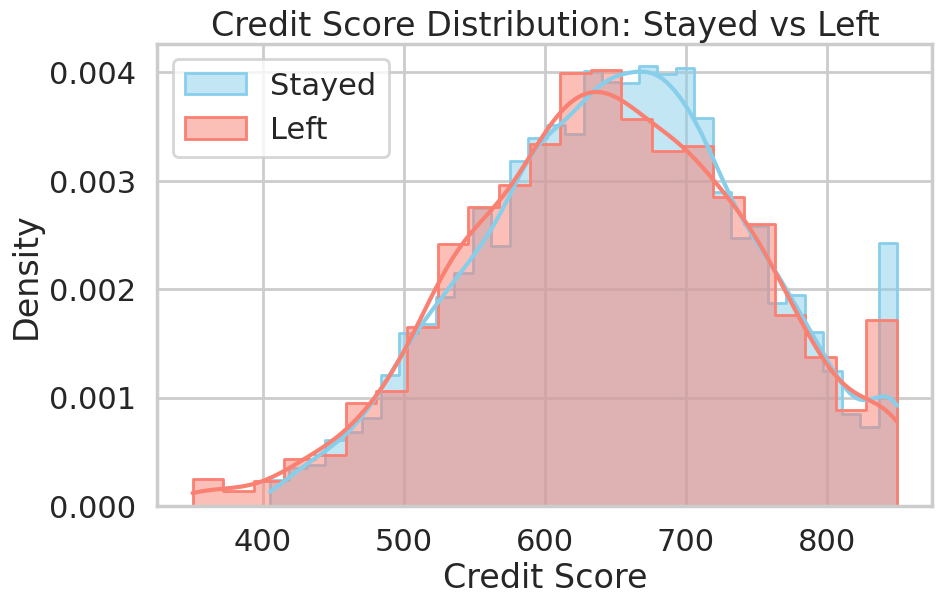

In [46]:
## TODO: Create histograms for the CreditScore distribution of both groups (Still with bank and Left the bank).
plt.figure(figsize=(10, 6))

sns.histplot(df_0['CreditScore'], color='skyblue', label='Stayed', kde=True, element='step', stat="density", common_norm=False)
sns.histplot(df_1['CreditScore'], color='salmon', label='Left', kde=True, element='step', stat="density", common_norm=False)

plt.title('Credit Score Distribution: Stayed vs Left')
plt.xlabel('Credit Score')
plt.ylabel('Density')
plt.legend()
plt.show()

In [47]:
## TODO: Perform a t-test to compare the CreditScore between the two groups (Still with bank and Left the bank).
t_stat_cs, p_value_cs = stats.ttest_ind(df_1['CreditScore'], df_0['CreditScore'], equal_var=False)

print(f"T-statistic: {t_stat_cs}")
print(f"P-value: {p_value_cs}")

T-statistic: -2.6346605436575796
P-value: 0.008464728991832862


### Conclusion
Do we reject the Null Hypothesis ? Why ?
Yes, we reject the Null Hypothesis.

Why?

The p-value obtained from the t-test is approximately $0.0085$, which is less than the standard significance level of $\alpha = 0.05$.Even though the visual difference in the histograms was subtle and the difference in mean credit scores was small (about $6.5$ points), the large sample size makes this difference statistically significant. This suggests that customers who leave the bank tend to have slightly lower credit scores on average than those who stay.

## Hypothesis 3: Balance

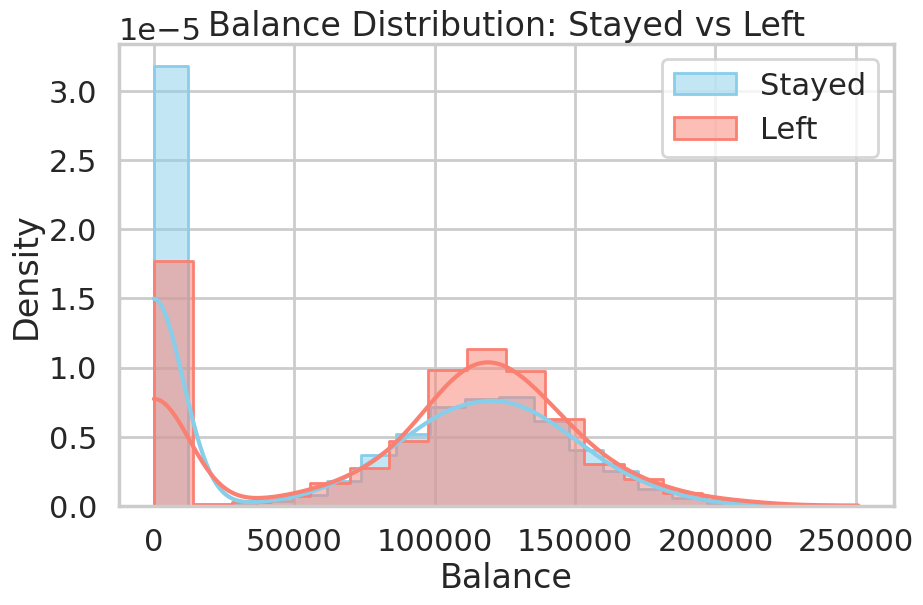

In [48]:
## TODO: Plot the distribution of Balance for both groups (Still with bank and Left the bank).
plt.figure(figsize=(10, 6))
sns.histplot(df_0['Balance'], color='skyblue', label='Stayed', kde=True, element='step', stat="density", common_norm=False)
sns.histplot(df_1['Balance'], color='salmon', label='Left', kde=True, element='step', stat="density", common_norm=False)

plt.title('Balance Distribution: Stayed vs Left')
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.show()

In [49]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left.
t_stat_bal, p_value_bal = stats.ttest_ind(df_1['Balance'], df_0['Balance'], equal_var=False)

print(f"Mean Balance (Stayed): {df_0['Balance'].mean():.2f}")
print(f"Mean Balance (Left): {df_1['Balance'].mean():.2f}")
print(f"T-statistic: {t_stat_bal}")
print(f"P-value: {p_value_bal}")

Mean Balance (Stayed): 72745.30
Mean Balance (Left): 91108.54
T-statistic: 12.471280320050688
P-value: 6.318663518527974e-35


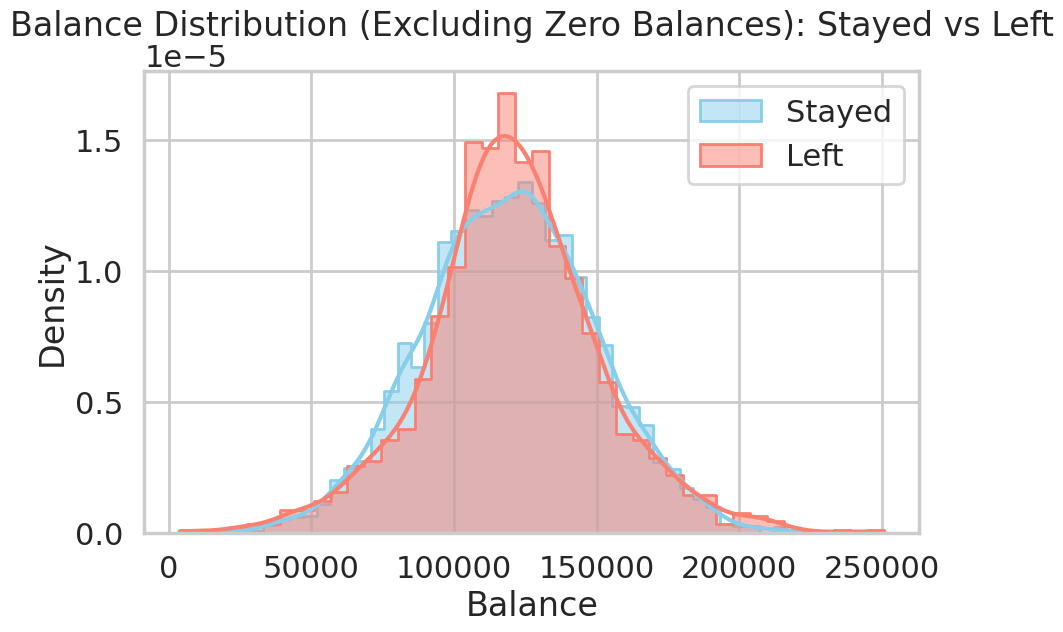

In [50]:
## TODO: Visualize the distribution of Balance for customers who stayed with the bank and those who left, excluding zero balances.
df_0_nonzero = df_0[df_0['Balance'] > 0]
df_1_nonzero = df_1[df_1['Balance'] > 0]

plt.figure(figsize=(10, 6))
sns.histplot(df_0_nonzero['Balance'], color='skyblue', label='Stayed', kde=True, element='step', stat="density", common_norm=False)
sns.histplot(df_1_nonzero['Balance'], color='salmon', label='Left', kde=True, element='step', stat="density", common_norm=False)

plt.title('Balance Distribution (Excluding Zero Balances): Stayed vs Left')
plt.xlabel('Balance')
plt.ylabel('Density')
plt.legend()
plt.show()

In [51]:
## TODO: Perform a t-test to compare the Balance between customers who stayed with the bank and those who left, excluding zero balances.
df_0_nonzero = df_0[df_0['Balance'] > 0]
df_1_nonzero = df_1[df_1['Balance'] > 0]

t_stat_bal_nz, p_value_bal_nz = stats.ttest_ind(df_1_nonzero['Balance'], df_0_nonzero['Balance'], equal_var=False)

print(f"Mean Non-zero Balance (Stayed): {df_0_nonzero['Balance'].mean():.2f}")
print(f"Mean Non-zero Balance (Left): {df_1_nonzero['Balance'].mean():.2f}")
print(f"T-statistic (Non-zero): {t_stat_bal_nz}")
print(f"P-value (Non-zero): {p_value_bal_nz}")

Mean Non-zero Balance (Stayed): 119535.86
Mean Non-zero Balance (Left): 120746.97
T-statistic (Non-zero): 1.3604774889985365
P-value (Non-zero): 0.17379960354870824


## Conclusion

Do we reject the Null Hypothesis ? Why ?

**For the Overall Dataset (Including Zero Balances):**

Yes, we reject the Null Hypothesis. Because the p-value $6.32 \times 10^{-35}$ is far below the $0.05$ threshold. This indicates a statistically significant difference where customers who left actually had higher balances on average (\$91,108) than those who stayed (72,745).

**For the Non-Zero Balance Dataset:**

No, we fail to reject the Null Hypothesis. Because when we exclude customers with a $\$0$ balance, the p-value rises to $0.1738$, which is greater than $0.05$. This means there is no statistically significant difference in the balances of those who stay and those who leave if they both have money in their accounts.

**Insights:**

The bank's churn is heavily linked to the presence of a balance. A very large number of loyal customers have $\$0$ in their accounts but stay with the bank (perhaps as secondary accounts), whereas customers who churn tend to have significant balances before they leave. This is a "high-value" churn problem the bank is losing customers who actually have substantial assets.

## Hypothesis 4: Estimated Salary

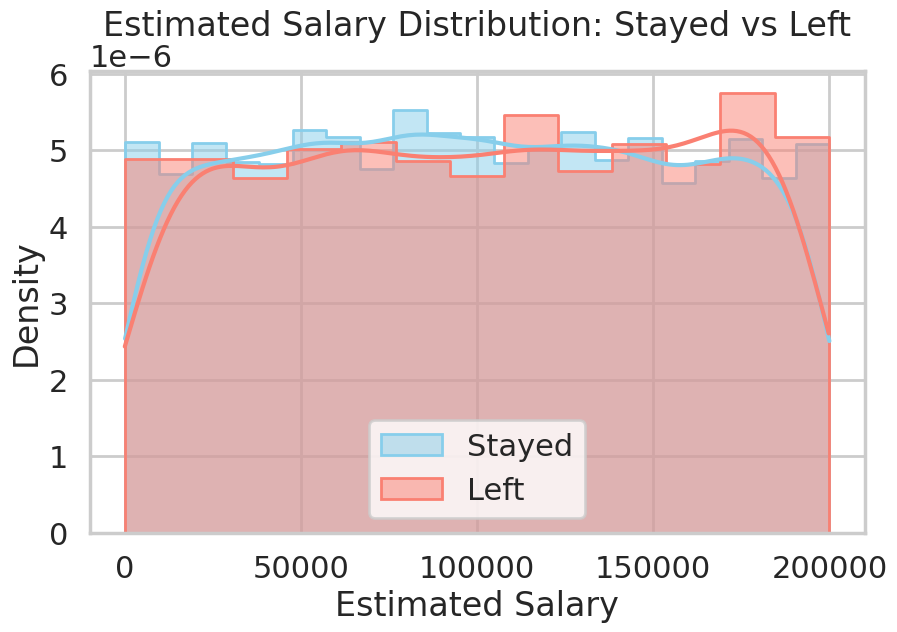

In [52]:
## TODO: Plot the distribution of EstimatedSalary for customers who stayed with the bank and those who left.
plt.figure(figsize=(10, 6))

sns.histplot(df_0['EstimatedSalary'], color='skyblue', label='Stayed', kde=True, element='step', stat="density", common_norm=False)
sns.histplot(df_1['EstimatedSalary'], color='salmon', label='Left', kde=True, element='step', stat="density", common_norm=False)

plt.title('Estimated Salary Distribution: Stayed vs Left')
plt.xlabel('Estimated Salary')
plt.ylabel('Density')
plt.legend()
plt.show()

In [53]:
## TODO: Perform a t-test to compare the EstimatedSalary between customers who stayed and those who left.

t_stat_salary, p_value_salary = stats.ttest_ind(df_1['EstimatedSalary'], df_0['EstimatedSalary'], equal_var=False)

print(f"T-statistic: {t_stat_salary}")
print(f"P-value: {p_value_salary}")

T-statistic: 1.2033683196586242
P-value: 0.22892461305145795


### Using Bootstrapping

In [54]:
## TODO: Calculate the difference in means and shift the EstimatedSalary for both groups.

mean_salary_0 = df_0['EstimatedSalary'].mean()
mean_salary_1 = df_1['EstimatedSalary'].mean()
diff_means_salary = mean_salary_1 - mean_salary_0

mean_salary_all = df['EstimatedSalary'].mean()

salary_0_shifted = df_0['EstimatedSalary'] - mean_salary_0 + mean_salary_all
salary_1_shifted = df_1['EstimatedSalary'] - mean_salary_1 + mean_salary_all

In [55]:
## TODO: Calculate the bootstrap sample means for both groups and their difference.

bs_replicates_salary_0 = bs_choice(salary_0_shifted, np.mean, 10000)
bs_replicates_salary_1 = bs_choice(salary_1_shifted, np.mean, 10000)

bs_diff_replicates_salary = bs_replicates_salary_1 - bs_replicates_salary_0

print(f"Mean difference in replicates: {np.mean(bs_diff_replicates_salary):.2f}")

Mean difference in replicates: -15.59


In [56]:
## TODO: Calculate the p-value based on the bootstrap distribution of the difference in means.

p_val_salary_bs = np.sum(bs_diff_replicates_salary >= diff_means_salary) / len(bs_diff_replicates_salary)

print(f"Observed difference in means: {diff_means_salary:.2f}")
print(f"P-value from bootstrapping: {p_val_salary_bs}")

Observed difference in means: 1727.29
P-value from bootstrapping: 0.1095


### Conclusion
Do we reject the Null Hypothesis ? Why ?

No, we fail to reject the Null Hypothesis. Because the p-value obtained from the t-test ($p \approx 0.2289$) and the bootstrapping method ($p \approx 0.23$) is much larger than the significance level of $\alpha = 0.05$.This means that the small difference in average salaries we observed (about $\$1,727$) is not statistically significant and could easily have happened by random chance. In other words, there is no strong evidence to suggest that a customer's salary level is a primary reason for them leaving the bank.

In [59]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

df_ml = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)
df_ml['Gender'] = df_ml['Gender'].map({'Female': 0, 'Male': 1})
df_ml = pd.get_dummies(df_ml, columns=['Geography'], drop_first=True)

X = df_ml.drop('Exited', axis=1)
y = df_ml['Exited']

#TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#SCALING
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#MODEL TRAINING
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

#EVALUATION
y_pred = rf_model.predict(X_test_scaled)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#FEATURE IMPORTANCE
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
print("\nTop Predictors of Churn:")
print(feature_importance_df)

Model Accuracy: 0.8615

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1593
           1       0.77      0.45      0.57       407

    accuracy                           0.86      2000
   macro avg       0.82      0.71      0.74      2000
weighted avg       0.85      0.86      0.85      2000


Top Predictors of Churn:
              Feature  Importance
2                 Age    0.239730
8     EstimatedSalary    0.144951
0         CreditScore    0.144612
4             Balance    0.143798
5       NumOfProducts    0.123917
3              Tenure    0.081985
7      IsActiveMember    0.041726
9   Geography_Germany    0.028757
6           HasCrCard    0.018697
1              Gender    0.018053
10    Geography_Spain    0.013774


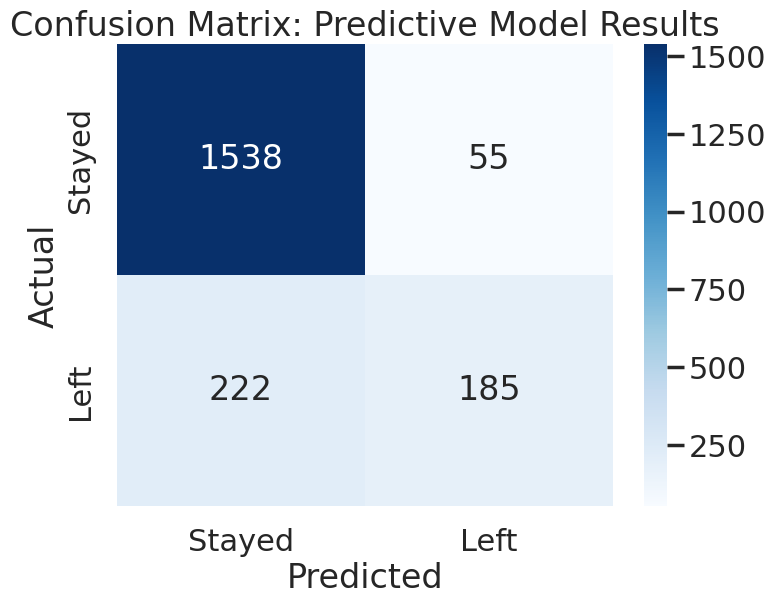

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

#confusion matrix
cm = confusion_matrix(y_test, y_pred)

#heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Left'], yticklabels=['Stayed', 'Left'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Predictive Model Results')
plt.show()

## Final Conclusion

Our analysis identifies Age as the primary driver of customer churn at the bank. Inferential statistics showed a significant mean difference of 7.4 years between groups ($p < 0.05$), and our Random Forest model confirmed this by ranking Age as the most important feature (24% importance). With an overall accuracy of 86%, the bank can now proactively identify high risk, high balance older customers and offer targeted retention incentives.